<img src="pic.jpg" alt="NDVI Logo" style="width:200px;height:auto;">

<font color=0F5298 size=6>
Add Images + Segmentation + Feature Creation
    <br>
    
    
<font color=696880 size=5>
<!-- <br> -->
November  17th 2024
<br>
K. N. Toosi University of Technology

<font color=696880 size=5>
<br>

<font color=GREEN size=5>
<br>
Mohammad Javad Soltani
<!-- <br> -->

____
    

<font color=Blue size=5>
<br>
Image Names
<!-- <br> -->

In [ ]:
import os
import re
from glob import glob
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats

# Define the path to the folder containing the images
folder_path = r'F:\_____My_Thesies____\_ImpFiles\1. Feature Generation\7. Raw Data\masterThesisImages'
print('Path has been conected? ', os. path. exists(folder_path))

tif_files = glob(os.path.join(folder_path, '*.tif'))

# Function to extract the year from the filename
def extract_year(filename):
    match = re.search(r'(\d{4})(\d{2})(\d{2})T', filename)
    if match:
        return int(match.group(1))
    return None
files_with_years = [(file, extract_year(os.path.basename(file))) for file in tif_files if extract_year(os.path.basename(file))]

def extract_date(filename):
    match = re.search(r'(\d{8})T', filename)
    if match:
        return int(match.group(1))  
    return None
files_sorted_by_date = sorted(files_with_years, key=lambda x: x[1])
files_sorted_by_date

Path has been conected?  True


[('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190126T073201_20190126T073159_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190307T072741_20190307T073745_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190312T073019_20190312T073512_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190322T072619_20190322T073719_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190421T072619_20190421T073927_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190506T072621_20190506T073100_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190511T072629_20190511T073412_T39STT.tif',
  2019),
 ('F:\\_____My_Thesies____\\_ImpFiles\\Sentinel_Data\\masterThesisImages\\20190516T072621_20190516T07333

____



<font color=Blue size=5>
<br>
Read & Plot Images
<!-- <br> -->

In [2]:
import rasterio
import numpy as np
from collections import defaultdict
 
image_collections = defaultdict(list)

def read_tif_image(filepath):
    with rasterio.open(filepath) as src:
        image_data = src.read()
        return image_data, src.profile  
for filepath, year in files_sorted_by_date:
    image_data, profile = read_tif_image(filepath)
    image_collections[year].append((image_data, profile))

for year, images in image_collections.items():
    print(f"Year: {year}, Number of Images: {len(images)}")
    
    for idx, (image_data, metadata) in enumerate(images):
        print(f"  Image {idx + 1}:")
        print(f"    Shape: {image_data.shape}") 
        print(f"    CRS: {metadata['crs']}") 
        print(f"    Resolution: {metadata['transform']}")


Year: 2019, Number of Images: 35
  Image 1:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288430.00|
| 0.00,-10.00, 3746240.00|
| 0.00, 0.00, 1.00|
  Image 2:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288430.00|
| 0.00,-10.00, 3746240.00|
| 0.00, 0.00, 1.00|
  Image 3:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288430.00|
| 0.00,-10.00, 3746240.00|
| 0.00, 0.00, 1.00|
  Image 4:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288430.00|
| 0.00,-10.00, 3746240.00|
| 0.00, 0.00, 1.00|
  Image 5:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288430.00|
| 0.00,-10.00, 3746240.00|
| 0.00, 0.00, 1.00|
  Image 6:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288430.00|
| 0.00,-10.00, 3746240.00|
| 0.00, 0.00, 1.00|
  Image 7:
    Shape: (13, 882, 720)
    CRS: EPSG:32639
    Resolution: | 10.00, 0.00, 288

In [3]:
def plot_rgb(image_data, profile, rgb_bands=(11, 10, 9), sigma=2, title="RGB Composite", enhance_contrast=False):
    """
    Plot an RGB composite using the given image data and the specified bands for R, G, and B.
    
    :param image_data: A 3D numpy array of shape (bands, rows, cols)
    :param profile: Metadata profile (for handling NoData values)
    :param rgb_bands: Tuple indicating the band indices for R, G, B (1-based indexing)
    :param sigma: Number of standard deviations (sigma) for clipping pixel values.
    :param title: Title for the plot
    :param enhance_contrast: If True, applies histogram equalization for better contrast (band-wise)
    """
    r = image_data[rgb_bands[0] - 1] 
    g = image_data[rgb_bands[1] - 1] 
    b = image_data[rgb_bands[2] - 1] 
    rgb_image = np.dstack((r, g, b))
    
    for i in range(3): 
        band_image = rgb_image[..., i]
        valid_mask = ~np.isnan(band_image) 
        
        if np.any(valid_mask):
            mean = np.mean(band_image[valid_mask])
            std_dev = np.std(band_image[valid_mask])

            lower_bound = mean - sigma * std_dev
            upper_bound = mean + sigma * std_dev
            band_image[valid_mask] = np.clip(band_image[valid_mask], lower_bound, upper_bound)

            band_image[valid_mask] = (band_image[valid_mask] - lower_bound) / (upper_bound - lower_bound)

            if enhance_contrast:
                band_image[valid_mask] = exposure.equalize_hist(band_image[valid_mask])

        rgb_image[..., i] = band_image

    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)
    plt.title(title)
    plt.axis('off')  
    plt.show()


Image Data Shape: (13, 882, 720)
Min Value per Band: [np.float32(2.0), np.float32(254.0), np.float32(309.0), np.float32(294.0), np.float32(330.0), np.float32(299.0), np.float32(317.0), np.float32(464.0), np.float32(366.0), np.float32(380.0), np.float32(88.0), np.float32(-36.340454), np.float32(-49.01191)]
Max Value per Band: [np.float32(11.0), np.float32(7459.0), np.float32(7032.0), np.float32(7134.0), np.float32(10648.0), np.float32(6831.0), np.float32(6505.0), np.float32(5498.0), np.float32(11593.0), np.float32(12400.0), np.float32(13400.0), np.float32(8.85545), np.float32(-5.7224917)]


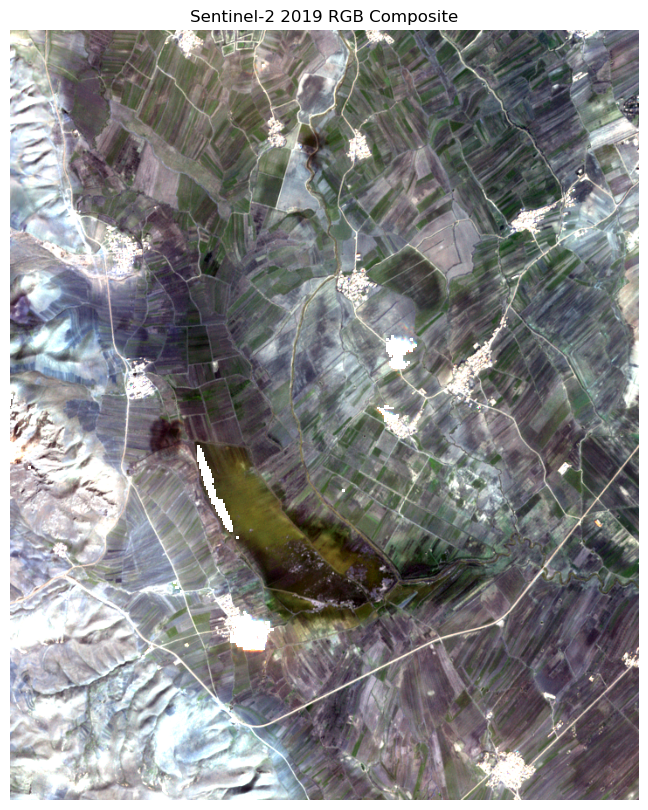

In [4]:
year = 2019
images = image_collections[year]
image_data, profile = images[0] 

# Check shape and print basic information
print("Image Data Shape:", image_data.shape)
print("Min Value per Band:", [np.nanmin(image_data[i]) for i in range(image_data.shape[0])])
print("Max Value per Band:", [np.nanmax(image_data[i]) for i in range(image_data.shape[0])])

plot_rgb(image_data, profile, rgb_bands=(11, 10, 9), sigma = 2, 
         title="Sentinel-2 2019 RGB Composite")


<font color=Blue size=5>
<br>
Create VIs
<!-- <br> -->

In [5]:
def read_tif_image(filepath):
    with rasterio.open(filepath) as src:
        image_data = src.read()
        return image_data, src.profile

In [6]:
def normalize_min_max(index_values):
    min_val = np.nanmin(index_values)
    max_val = np.nanmax(index_values)
    if max_val - min_val == 0:
        return np.zeros_like(index_values)
    return 2 * ((index_values - min_val) / (max_val - min_val)) - 1


In [7]:
def calculate_all_indices(image_data):
    indices = {}
    blue = image_data[10]     / 10000 
    green = image_data[9]     / 10000  
    red = image_data[8]       / 10000 
    nir = image_data[4]       / 10000 
    red_edge3 = image_data[5] / 10000
    red_edge = image_data[6]  / 10000  # Red Edge 2 
    red_edge1 = image_data[7] / 10000 
    red_edge4 = image_data[3] / 10000 
    swir1 = image_data[2]     / 10000
    swir2 = image_data[1]     / 10000
    L = 0.5  
      
    indices['NDVI'] = (nir - red) / (nir + red)
    indices['EVI'] = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
    indices['SAVI'] = ((nir - red) / (nir + red + L)) * (1 + L)
    indices['TDVI'] = 1.5 * ((nir - red) / np.sqrt((nir ** 2 + red + 0.5)))
    indices['NDWI'] = (green - nir) / (green + nir)
    indices['2BDA'] = (red_edge1) / (red)  
    indices['NDCI'] = (red_edge1 - red) / (red_edge1 + red)
    indices['ENDVI'] = ((nir + green) - 2 * blue) / ((nir + green) + 2 * blue) 
    indices['GNDVI'] = (nir - green) / (nir + green)
    indices['NDRE'] = (nir - red_edge) / (nir + red_edge)
    indices['GRVI'] = nir / green 
    indices['MSAVI'] = (2 * nir + 1 - np.sqrt((2 * nir + 1) ** 2 - 8 * (nir - red))) / 2
    indices['LSWI'] = (nir - swir1) / (nir + swir1)                 
    indices['NDMI'] = (nir - swir1) / (nir + swir1)
    indices['MNDWI'] = (green - swir1) / (green + swir1)
    indices['MBI'] = ((swir1 - swir2 - nir) / (swir1 + swir2 + nir))  + 0.5                             
    indices['EMBI'] = (indices['MBI'] - indices['MNDWI'] - 0.5) / (indices['MBI'] + indices['MNDWI'] + 1.5) 
    indices['MCARI2'] = 1.5 * ( 2.5 * (nir - red) - 1.3 * (nir - green)) / np.sqrt((2 * nir + 1) ** 2 - (6 * nir - 5 * np.sqrt(red)) - 0.5)
    
    normalized_indices = {key: normalize_min_max(value) for key, value in indices.items()}
    image_data_new = image_data[1:]
    image_data_new[:9] = image_data_new[:9] / 10000
    image_data_new[10] = normalize_min_max(image_data_new[10])  
    image_data_new[11] = normalize_min_max(image_data_new[11])  

    image_data_new = np.concatenate([image_data_new] + [np.expand_dims(normalized_indices[key], axis=0) for key in normalized_indices], axis=0)

    return image_data_new

In [8]:
S2_VI = calculate_all_indices(image_data)


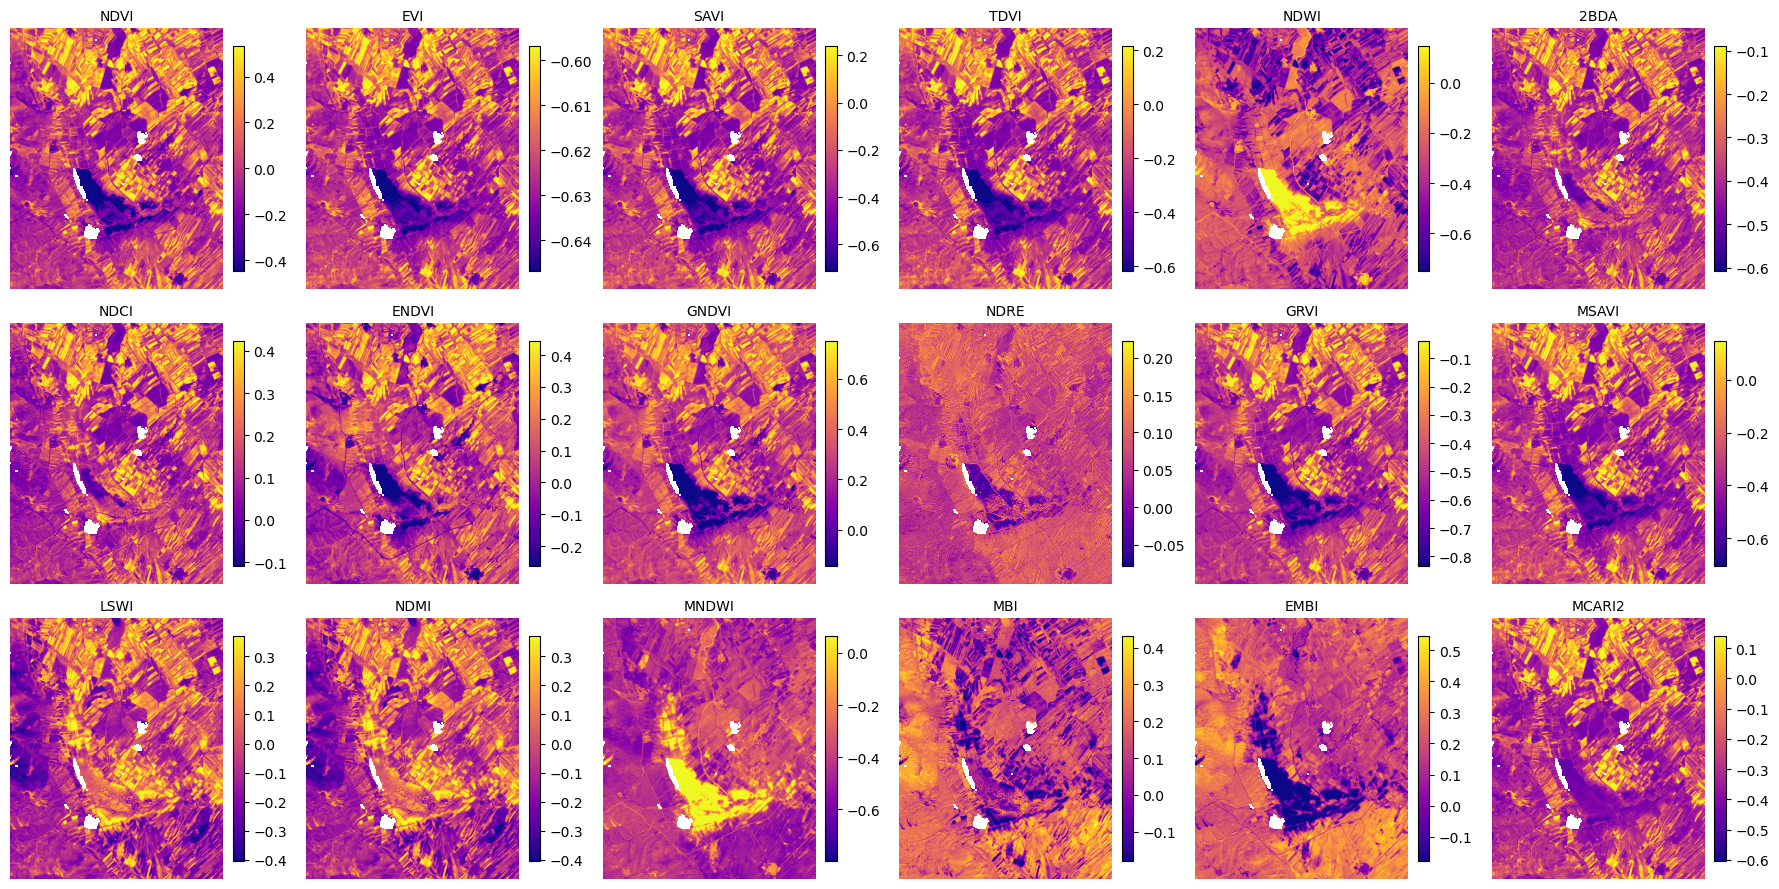

In [9]:
index_titles = ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI','GNDVI',
                'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 'MBI','EMBI', 'MCARI2']

def plot_all_indices(S2_VI):
    indices = S2_VI[12:]
    num_indices = indices.shape[0]
    cols = 6  
    rows = (num_indices + cols - 1) // cols  

    # Create the plot
    fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows))
    axes = axes.ravel() 

    for i in range(num_indices):
        index_values = indices[i]  
        mean = np.nanmean(index_values)
        std_dev = np.nanstd(index_values)
        lower_bound = mean - 2 * std_dev
        upper_bound = mean + 2 * std_dev
        clipped_values = np.clip(index_values, lower_bound, upper_bound)

        ax = axes[i]
        im = ax.imshow(clipped_values, cmap='plasma', vmin=lower_bound, vmax=upper_bound)
        ax.set_title(f'{index_titles[i]}', fontsize=10)
        ax.axis('off') 
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for j in range(num_indices, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
plot_all_indices(S2_VI)


In [10]:
vi_collections = defaultdict(list)
for year, images in image_collections.items():
    print(f"Processing year: {year}, Number of images: {len(images)}")
    for idx, (image_data, metadata) in enumerate(images):
        print(f"  Processing image {idx + 1} for year {year}")
        vi_image_data = calculate_all_indices(image_data)
        new_metadata = metadata.copy()
        new_metadata['count'] = vi_image_data.shape[0]  
        vi_collections[year].append((vi_image_data, new_metadata))

Processing year: 2019, Number of images: 35
  Processing image 1 for year 2019
  Processing image 2 for year 2019
  Processing image 3 for year 2019
  Processing image 4 for year 2019
  Processing image 5 for year 2019
  Processing image 6 for year 2019
  Processing image 7 for year 2019
  Processing image 8 for year 2019
  Processing image 9 for year 2019
  Processing image 10 for year 2019
  Processing image 11 for year 2019
  Processing image 12 for year 2019
  Processing image 13 for year 2019
  Processing image 14 for year 2019
  Processing image 15 for year 2019
  Processing image 16 for year 2019
  Processing image 17 for year 2019
  Processing image 18 for year 2019
  Processing image 19 for year 2019
  Processing image 20 for year 2019
  Processing image 21 for year 2019
  Processing image 22 for year 2019
  Processing image 23 for year 2019
  Processing image 24 for year 2019
  Processing image 25 for year 2019
  Processing image 26 for year 2019
  Processing image 27 for yea

C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:16: RuntimeWarning: divide by zero encountered in divide
  indices['EVI'] = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\533218531.py:6: RuntimeWarning: invalid value encountered in subtract
  return 2 * ((index_values - min_val) / (max_val - min_val)) - 1
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\533218531.py:6: RuntimeWarning: invalid value encountered in divide
  return 2 * ((index_values - min_val) / (max_val - min_val)) - 1


  Processing image 2 for year 2020
  Processing image 3 for year 2020
  Processing image 4 for year 2020
  Processing image 5 for year 2020
  Processing image 6 for year 2020
  Processing image 7 for year 2020
  Processing image 8 for year 2020
  Processing image 9 for year 2020
  Processing image 10 for year 2020
  Processing image 11 for year 2020
  Processing image 12 for year 2020
  Processing image 13 for year 2020
  Processing image 14 for year 2020
  Processing image 15 for year 2020
  Processing image 16 for year 2020
  Processing image 17 for year 2020
  Processing image 18 for year 2020
  Processing image 19 for year 2020
  Processing image 20 for year 2020
  Processing image 21 for year 2020
  Processing image 22 for year 2020
  Processing image 23 for year 2020
  Processing image 24 for year 2020
  Processing image 25 for year 2020
  Processing image 26 for year 2020
  Processing image 27 for year 2020
  Processing image 28 for year 2020
  Processing image 29 for year 2020


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:20: RuntimeWarning: divide by zero encountered in divide
  indices['2BDA'] = (red_edge1) / (red)
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:25: RuntimeWarning: divide by zero encountered in divide
  indices['GRVI'] = nir / green


  Processing image 2 for year 2022
  Processing image 3 for year 2022
  Processing image 4 for year 2022
  Processing image 5 for year 2022
  Processing image 6 for year 2022
  Processing image 7 for year 2022
  Processing image 8 for year 2022
  Processing image 9 for year 2022
  Processing image 10 for year 2022
  Processing image 11 for year 2022
  Processing image 12 for year 2022
  Processing image 13 for year 2022
  Processing image 14 for year 2022
  Processing image 15 for year 2022
  Processing image 16 for year 2022
  Processing image 17 for year 2022
  Processing image 18 for year 2022
  Processing image 19 for year 2022
  Processing image 20 for year 2022
  Processing image 21 for year 2022
  Processing image 22 for year 2022
  Processing image 23 for year 2022
  Processing image 24 for year 2022
  Processing image 25 for year 2022


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:24: RuntimeWarning: invalid value encountered in divide
  indices['NDRE'] = (nir - red_edge) / (nir + red_edge)


Processing year: 2023, Number of images: 21
  Processing image 1 for year 2023
  Processing image 2 for year 2023
  Processing image 3 for year 2023
  Processing image 4 for year 2023
  Processing image 5 for year 2023
  Processing image 6 for year 2023
  Processing image 7 for year 2023
  Processing image 8 for year 2023
  Processing image 9 for year 2023
  Processing image 10 for year 2023
  Processing image 11 for year 2023
  Processing image 12 for year 2023
  Processing image 13 for year 2023
  Processing image 14 for year 2023
  Processing image 15 for year 2023
  Processing image 16 for year 2023
  Processing image 17 for year 2023
  Processing image 18 for year 2023
  Processing image 19 for year 2023
  Processing image 20 for year 2023
  Processing image 21 for year 2023
Processing year: 2024, Number of images: 15
  Processing image 1 for year 2024
  Processing image 2 for year 2024
  Processing image 3 for year 2024


C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:15: RuntimeWarning: invalid value encountered in divide
  indices['NDVI'] = (nir - red) / (nir + red)
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:19: RuntimeWarning: invalid value encountered in divide
  indices['NDWI'] = (green - nir) / (green + nir)
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:20: RuntimeWarning: invalid value encountered in divide
  indices['2BDA'] = (red_edge1) / (red)
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:21: RuntimeWarning: invalid value encountered in divide
  indices['NDCI'] = (red_edge1 - red) / (red_edge1 + red)
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:22: RuntimeWarning: invalid value encountered in divide
  indices['ENDVI'] = ((nir + green) - 2 * blue) / ((nir + green) + 2 * blue)
C:\Users\mamad_js\AppData\Local\Temp\ipykernel_5820\4118530297.py:23: RuntimeWarning: invalid value encountered in divi

  Processing image 4 for year 2024
  Processing image 5 for year 2024
  Processing image 6 for year 2024
  Processing image 7 for year 2024
  Processing image 8 for year 2024
  Processing image 9 for year 2024
  Processing image 10 for year 2024
  Processing image 11 for year 2024
  Processing image 12 for year 2024
  Processing image 13 for year 2024
  Processing image 14 for year 2024
  Processing image 15 for year 2024


________

<font color=Blue size=5>
<br>
Create GLCM
<!-- <br> -->

In [22]:
with rasterio.open('F:/_____My_Thesies____/_ImpFiles/Sentinel_Data/masterThesisImages/NIR_Stack_GLCM.tif') as src:
    glcm_data = src.read() 
    normalized_glcm = np.zeros_like(glcm_data, dtype=np.float32)

    for i in range(glcm_data.shape[0]):
        band = glcm_data[i, :, :]
        min_val = np.min(band)
        max_val = np.max(band)
        
        if max_val - min_val != 0:  # Avoid division by zero
            normalized_glcm[i, :, :] = (band - min_val) / (max_val - min_val)
        else:
            normalized_glcm[i, :, :] = band  



In [28]:
glcm_bands_per_image = 8
num_images = normalized_glcm.shape[0] // glcm_bands_per_image
glcm_per_image_reversed = np.flip(normalized_glcm, axis=0)
glcm_index = 0

for year, images in vi_collections.items():
    print(f"Processing GLCM for year: {year}, Number of images: {len(images)}")
    
    for idx, (vi_image_data, metadata) in enumerate(images):
        print(f"  Processing image {idx + 1} for year {year}")
        glcm_bands = glcm_per_image_reversed[glcm_index:glcm_index + glcm_bands_per_image, :, :]
        glcm_index += glcm_bands_per_image
        
        vi_image_data_with_glcm = np.concatenate([vi_image_data, glcm_bands], axis=0)
        new_metadata = metadata.copy()
        new_metadata['count'] = vi_image_data_with_glcm.shape[0]  # Update number of bands
        
        vi_collections[year][idx] = (vi_image_data_with_glcm, new_metadata)


Processing GLCM for year: 2019, Number of images: 35
  Processing image 1 for year 2019
  Processing image 2 for year 2019
  Processing image 3 for year 2019
  Processing image 4 for year 2019
  Processing image 5 for year 2019
  Processing image 6 for year 2019
  Processing image 7 for year 2019
  Processing image 8 for year 2019
  Processing image 9 for year 2019
  Processing image 10 for year 2019
  Processing image 11 for year 2019
  Processing image 12 for year 2019
  Processing image 13 for year 2019
  Processing image 14 for year 2019
  Processing image 15 for year 2019
  Processing image 16 for year 2019
  Processing image 17 for year 2019
  Processing image 18 for year 2019
  Processing image 19 for year 2019
  Processing image 20 for year 2019
  Processing image 21 for year 2019
  Processing image 22 for year 2019
  Processing image 23 for year 2019
  Processing image 24 for year 2019
  Processing image 25 for year 2019
  Processing image 26 for year 2019
  Processing image 2

In [42]:
# Sample first image:
vi_collections[2019][0]

(array([[[1.9859999e-05, 2.0160000e-05, 2.0160000e-05, ...,
          1.8010000e-05, 1.8010000e-05, 1.8810000e-05],
         [1.9859999e-05, 2.0160000e-05, 2.0160000e-05, ...,
          1.8010000e-05, 1.8010000e-05, 1.8810000e-05],
         [1.9879999e-05, 2.0760001e-05, 2.0760001e-05, ...,
          1.8110000e-05, 1.8110000e-05, 1.7710001e-05],
         ...,
         [2.3240000e-05, 2.3610000e-05, 2.3610000e-05, ...,
          1.8140001e-05, 1.8140001e-05, 1.7630000e-05],
         [2.3990000e-05, 2.4569999e-05, 2.4569999e-05, ...,
          1.6580001e-05, 1.6580001e-05, 1.4849999e-05],
         [2.3990000e-05, 2.4569999e-05, 2.4569999e-05, ...,
          1.6580001e-05, 1.6580001e-05, 1.4849999e-05]],
 
        [[2.6409998e-05, 2.6710000e-05, 2.6710000e-05, ...,
          2.2000000e-05, 2.2000000e-05, 2.2560000e-05],
         [2.6409998e-05, 2.6710000e-05, 2.6710000e-05, ...,
          2.2000000e-05, 2.2000000e-05, 2.2560000e-05],
         [2.6640000e-05, 2.7410000e-05, 2.7410000e-05, 

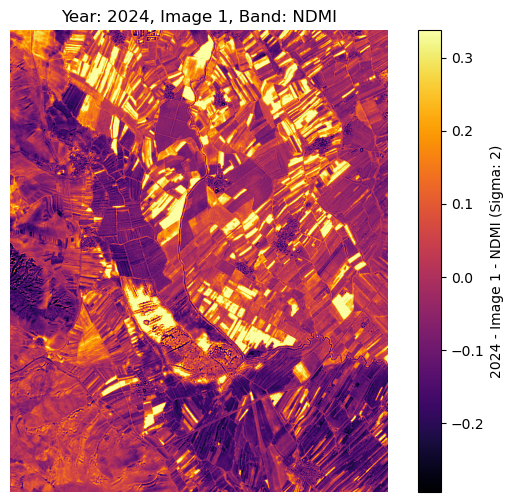

In [43]:
import matplotlib.colors as mcolors

BAND_NAMES = [
    "B12", "B11", "B8A", "B8", "B7", "B6", "B5", "B4", "B3", "B2",  
    "VV", "VH", 
    'NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 'MBI', 'EMBI', 'MCARI2',  
    'GLCM Mean', 'GLCM Variance', 'GLCM Homogeneity', 'GLCM Contrast', 'GLCM Dissimilarity', 'GLCM Entropy', 'GLCM Second Moment', 'GLCM Correlation' 
]

def plot_band(vi_collections, year, image_idx, band_idx, sigma=2, cmap='viridis'):
    """
    Plots a specific band from an image in a specific year with sigma clipping and a custom colormap.
    
    Parameters:
    - vi_collections: Dictionary containing image data across years and images.
    - year: The year of the image you want to plot.
    - image_idx: The index of the image in that year to plot.
    - band_idx: The index of the band in the image you want to plot.
    - sigma: The number of standard deviations to use for sigma clipping (default is 2).
    - cmap: The colormap to use for plotting (default is 'viridis').
    """
    image_data, metadata = vi_collections[year][image_idx]
    band_data = image_data[band_idx, :, :]
    mean_val = np.mean(band_data)
    std_val = np.std(band_data)
    
    vmin = mean_val - sigma * std_val
    vmax = mean_val + sigma * std_val
    clipped_band = np.clip(band_data, vmin, vmax)
    
    if 0 <= band_idx < len(BAND_NAMES):
        band_name = BAND_NAMES[band_idx]
    else:
        band_name = f"Band {band_idx}"
    
    plt.figure(figsize=(8, 6))
    plt.imshow(clipped_band, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label=f'{year} - Image {image_idx+1} - {band_name} (Sigma: {sigma})')
    plt.title(f'Year: {year}, Image {image_idx + 1}, Band: {band_name}')
    plt.axis('off')
    plt.show()


plot_band(vi_collections, year=2024, image_idx=0, band_idx=25, sigma=2, cmap='inferno')


<font color=Blue size=5>
<br>
Export Results
<!-- <br> -->

In [44]:
from rasterio.transform import from_origin

def export_all_images_as_tif(vi_collections, output_dir):
    """
    Exports all images with all bands (spectral, indices, and GLCM features) to GeoTIFF format.
    
    Parameters:
    - vi_collections: Dictionary containing image data across years and images.
    - output_dir: Directory where the images will be saved.
    """
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for year, images in vi_collections.items():
        print(f"Exporting images for year: {year}")
        year_dir = os.path.join(output_dir, str(year))
        if not os.path.exists(year_dir):
            os.makedirs(year_dir)
        for image_idx, (image_data, metadata) in enumerate(images):
            print(f"  Processing image {image_idx + 1}")
            image_dir = os.path.join(year_dir, f"image_{image_idx + 1}")
            if not os.path.exists(image_dir):
                os.makedirs(image_dir)
            output_file = os.path.join(image_dir, f"image_{image_idx + 1}.tif")
            new_metadata = metadata.copy()
            new_metadata.update({
                'count': image_data.shape[0],  # Number of bands
                'dtype': image_data.dtype,     # Data type of the bands
                'driver': 'GTiff',             # Output format is GeoTIFF
                'compress': 'lzw'              # Optional compression (LZW to reduce file size)
            })
            
            with rasterio.open(output_file, 'w', **new_metadata) as dst:
                for band_idx in range(image_data.shape[0]):
                    dst.write(image_data[band_idx, :, :], band_idx + 1)
    
    print("GeoTIFF export complete!")
export_all_images_as_tif(vi_collections, output_dir="F:/_____My_Thesies____/_ImpFiles/Sentinel_Data/masterThesisImages/VI_GLCM_Added")


Exporting images for year: 2019
  Processing image 1
  Processing image 2
  Processing image 3
  Processing image 4
  Processing image 5
  Processing image 6
  Processing image 7
  Processing image 8
  Processing image 9
  Processing image 10
  Processing image 11
  Processing image 12
  Processing image 13
  Processing image 14
  Processing image 15
  Processing image 16
  Processing image 17
  Processing image 18
  Processing image 19
  Processing image 20
  Processing image 21
  Processing image 22
  Processing image 23
  Processing image 24
  Processing image 25
  Processing image 26
  Processing image 27
  Processing image 28
  Processing image 29
  Processing image 30
  Processing image 31
  Processing image 32
  Processing image 33
  Processing image 34
  Processing image 35
Exporting images for year: 2020
  Processing image 1
  Processing image 2
  Processing image 3
  Processing image 4
  Processing image 5
  Processing image 6
  Processing image 7
  Processing image 8
  Proce

____